<a href="https://colab.research.google.com/github/m2nwo079/global-challenger-2026/blob/main/03_module_c.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil, sqlite3, csv, itertools, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = '/content/drive/MyDrive/globalchallenger'
WORK = '/content/work'
DB   = f'{WORK}/data/db/criteo.db'

os.makedirs(f'{WORK}/data/raw', exist_ok=True)
os.makedirs(f'{WORK}/data/db',  exist_ok=True)
if not os.path.exists(DB):
    print('Copying DB from Drive...')
    shutil.copy(f'{BASE}/data/db/criteo.db', DB)

con = sqlite3.connect(DB)
con.execute('PRAGMA cache_size = -800000')
con.execute('PRAGMA temp_store = MEMORY')

plt.rcParams['savefig.dpi']  = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.unicode_minus'] = False
print('ok')

Mounted at /content/drive
Copying DB from Drive...
ok


In [2]:
%cd {WORK}/data/raw
!curl -L -o uplift.csv.gz http://go.criteo.net/criteo-research-uplift-v2.1.csv.gz
!ls -lh uplift.csv.gz

/content/work/data/raw
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  296M  100  296M    0     0  23.1M      0  0:00:12  0:00:12 --:--:-- 21.1M
-rw-r--r-- 1 root root 297M Aug  3 18:01 uplift.csv.gz


In [3]:
GZ = f'{WORK}/data/raw/uplift.csv.gz'
!zcat {GZ} | head -3
!zcat {GZ} | wc -l

f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
12.616364906986497,10.059654474774547,8.976428838331028,4.679881620097284,10.280525225748212,4.115453421277861,0.29444271125560606,4.833814577796811,3.9553959684262416,13.190055934673358,5.300374864042156,-0.16867922100056124,1,0,0,0
12.616364906986497,10.059654474774547,9.002689495197341,4.679881620097284,10.280525225748212,4.115453421277861,0.29444271125560606,4.833814577796811,3.9553959684262416,13.190055934673358,5.300374864042156,-0.16867922100056124,1,0,0,0
13979593


In [4]:
FEATS = [f'f{i}' for i in range(12)]
COLS  = FEATS + ['treatment', 'conversion', 'visit', 'exposure']
NCOL  = len(COLS)

ddl = ',\n    '.join(
    [f'{c} REAL' for c in FEATS] +
    [f'{c} INTEGER' for c in ['treatment', 'conversion', 'visit', 'exposure']])

con.executescript(f"""
PRAGMA journal_mode = OFF;
PRAGMA synchronous = OFF;
DROP TABLE IF EXISTS uplift;
CREATE TABLE uplift (
    {ddl}
);
""")
con.commit()
print(con.execute("PRAGMA table_info(uplift)").fetchall())

[(0, 'f0', 'REAL', 0, None, 0), (1, 'f1', 'REAL', 0, None, 0), (2, 'f2', 'REAL', 0, None, 0), (3, 'f3', 'REAL', 0, None, 0), (4, 'f4', 'REAL', 0, None, 0), (5, 'f5', 'REAL', 0, None, 0), (6, 'f6', 'REAL', 0, None, 0), (7, 'f7', 'REAL', 0, None, 0), (8, 'f8', 'REAL', 0, None, 0), (9, 'f9', 'REAL', 0, None, 0), (10, 'f10', 'REAL', 0, None, 0), (11, 'f11', 'REAL', 0, None, 0), (12, 'treatment', 'INTEGER', 0, None, 0), (13, 'conversion', 'INTEGER', 0, None, 0), (14, 'visit', 'INTEGER', 0, None, 0), (15, 'exposure', 'INTEGER', 0, None, 0)]


In [5]:
%%time
import gzip

cur = con.cursor()
sql = f"INSERT INTO uplift VALUES ({','.join('?' * NCOL)})"
n = 0

with gzip.open(GZ, 'rt', newline='') as f:
    r = csv.reader(f, quoting=csv.QUOTE_NONE)
    header = next(r)
    assert header == COLS, f'column order mismatch:\n{header}\n{COLS}'
    while True:
        chunk = list(itertools.islice(r, 200_000))
        if not chunk:
            break
        cur.executemany(sql, chunk)
        con.commit()
        n += len(chunk)
        print(f'{n:,}', end='\r')

con.commit()
print(f'\nLoaded {n:,} rows')

13,979,592
Loaded 13,979,592 rows
CPU times: user 3min 30s, sys: 11.9 s, total: 3min 42s
Wall time: 3min 50s


In [6]:
print(pd.read_sql_query("""
SELECT typeof(f0) f0, typeof(treatment) trt, typeof(visit) vis,
       typeof(conversion) conv, typeof(exposure) exp
FROM uplift LIMIT 1
""", con))

print(pd.read_sql_query("""
SELECT COUNT(*)        AS rows,
       AVG(treatment)  AS treatment_ratio,
       AVG(visit)      AS visit_rate,
       AVG(conversion) AS conversion_rate,
       AVG(exposure)   AS exposure_rate,
       MIN(treatment) || '/' || MAX(treatment)   AS trt_range,
       MIN(visit)     || '/' || MAX(visit)       AS vis_range,
       MIN(conversion)|| '/' || MAX(conversion)  AS conv_range
FROM uplift
""", con).T)

     f0      trt      vis     conv      exp
0  real  integer  integer  integer  integer
                        0
rows             13979592
treatment_ratio      0.85
visit_rate       0.046992
conversion_rate  0.002917
exposure_rate    0.030631
trt_range             0/1
vis_range             0/1
conv_range            0/1


In [7]:
%%time
!cp {DB} {BASE}/data/db/criteo.db
!ls -lh {BASE}/data/db

total 2.5G
-rw------- 1 root root 2.5G Aug  3 18:08 criteo.db
CPU times: user 65.5 ms, sys: 5.19 ms, total: 70.7 ms
Wall time: 26.6 s


In [8]:
base = pd.read_sql_query("""
SELECT treatment,
       COUNT(*)        AS n,
       SUM(visit)      AS visits,
       SUM(conversion) AS conversions
FROM uplift GROUP BY treatment ORDER BY treatment
""", con)
print(base.to_string(index=False))

def ate(outcome):
    r = base.set_index('treatment')
    n_c, n_t = r.loc[0, 'n'], r.loc[1, 'n']
    y_c, y_t = r.loc[0, outcome], r.loc[1, outcome]
    p_c, p_t = y_c / n_c, y_t / n_t

    diff = p_t - p_c
    se_d = np.sqrt(p_t * (1 - p_t) / n_t + p_c * (1 - p_c) / n_c)

    log_ratio = np.log(p_t / p_c)
    se_lr = np.sqrt((1 - p_t) / (p_t * n_t) + (1 - p_c) / (p_c * n_c))
    lo, hi = np.exp(log_ratio - 1.96 * se_lr), np.exp(log_ratio + 1.96 * se_lr)

    return {
        'outcome': outcome,
        'rate_control': p_c, 'rate_treated': p_t,
        'n_control': int(n_c), 'n_treated': int(n_t),
        'events_control': int(y_c), 'events_treated': int(y_t),
        'abs_lift': diff,
        'abs_ci_low': diff - 1.96 * se_d, 'abs_ci_high': diff + 1.96 * se_d,
        'rel_lift': lo * 0 + (p_t / p_c - 1),
        'rel_ci_low': lo - 1, 'rel_ci_high': hi - 1,
        'incremental_share': diff / p_t,
        'z': diff / se_d,
    }

itt = pd.DataFrame([ate('visits'), ate('conversions')])
pd.set_option('display.width', 200)
print()
print(itt[['outcome', 'rate_control', 'rate_treated', 'abs_lift',
           'abs_ci_low', 'abs_ci_high']].to_string(index=False,
                                                   float_format='%.6f'))
print()
print(itt[['outcome', 'rel_lift', 'rel_ci_low', 'rel_ci_high',
           'incremental_share', 'z']].to_string(index=False,
                                                float_format='%.4f'))

 treatment        n  visits  conversions
         0  2096937   80105         4063
         1 11882655  576824        36711

    outcome  rate_control  rate_treated  abs_lift  abs_ci_low  abs_ci_high
     visits      0.038201      0.048543  0.010342    0.010056     0.010629
conversions      0.001938      0.003089  0.001152    0.001085     0.001219

    outcome  rel_lift  rel_ci_low  rel_ci_high  incremental_share       z
     visits    0.2707      0.2616       0.2800             0.2131 70.6852
conversions    0.5945      0.5437       0.6470             0.3728 33.5123


In [9]:
print(pd.read_sql_query("""
SELECT treatment, COUNT(*) AS n, SUM(exposure) AS exposed,
       AVG(exposure) AS exposure_rate
FROM uplift GROUP BY treatment ORDER BY treatment
""", con))

wrong = pd.read_sql_query("""
SELECT CASE WHEN treatment = 1 AND exposure = 1 THEN 'exposed'
            WHEN treatment = 0                  THEN 'control'
            ELSE 'excluded' END AS grp,
       COUNT(*) AS n, SUM(visit) AS visits, SUM(conversion) AS conversions
FROM uplift GROUP BY grp
""", con)
print()
print(wrong.to_string(index=False))

w = wrong.set_index('grp')
rows = []
for oc in ['visits', 'conversions']:
    p_c = w.loc['control', oc] / w.loc['control', 'n']
    p_e = w.loc['exposed', oc] / w.loc['exposed', 'n']
    itt_rel = itt.set_index('outcome').loc[oc, 'rel_lift']
    rows.append({'outcome': oc, 'itt_rel_lift': itt_rel,
                 'exposed_vs_control_rel_lift': p_e / p_c - 1,
                 'inflation_factor': (p_e / p_c - 1) / itt_rel})
print()
print(pd.DataFrame(rows).to_string(index=False, float_format='%.4f'))

   treatment         n  exposed  exposure_rate
0          0   2096937        0       0.000000
1          1  11882655   428212       0.036037

     grp        n  visits  conversions
 control  2096937   80105         4063
excluded 11454443  399314        13680
 exposed   428212  177510        23031

    outcome  itt_rel_lift  exposed_vs_control_rel_lift  inflation_factor
     visits        0.2707                       9.8515           36.3877
conversions        0.5945                      26.7583           45.0106


In [10]:
g = wrong.set_index('grp')
c = 0.036037

rows = []
for oc in ['visits', 'conversions']:
    n_c,  y_c  = g.loc['control',  'n'], g.loc['control',  oc]
    n_nt, y_nt = g.loc['excluded', 'n'], g.loc['excluded', oc]
    n_e,  y_e  = g.loc['exposed',  'n'], g.loc['exposed',  oc]

    p_c  = y_c  / n_c
    p_nt = y_nt / n_nt
    p_e  = y_e  / n_e

    p_comp_baseline = (p_c - (1 - c) * p_nt) / c
    late = p_e - p_comp_baseline
    itt_abs = itt.set_index('outcome').loc[oc, 'abs_lift']

    rows.append({
        'outcome': oc,
        'never_taker_rate': p_nt,
        'control_rate': p_c,
        'complier_baseline': p_comp_baseline,
        'exposed_rate': p_e,
        'late': late,
        'late_check_itt_over_c': itt_abs / c,
        'incremental_share_exposed': late / p_e,
    })

late_df = pd.DataFrame(rows)
print(late_df.to_string(index=False, float_format='%.6f'))

    outcome  never_taker_rate  control_rate  complier_baseline  exposed_rate     late  late_check_itt_over_c  incremental_share_exposed
     visits          0.034861      0.038201           0.127541      0.414538 0.286997               0.286994                   0.692330
conversions          0.001194      0.001938           0.021820      0.053784 0.031964               0.031964                   0.594302


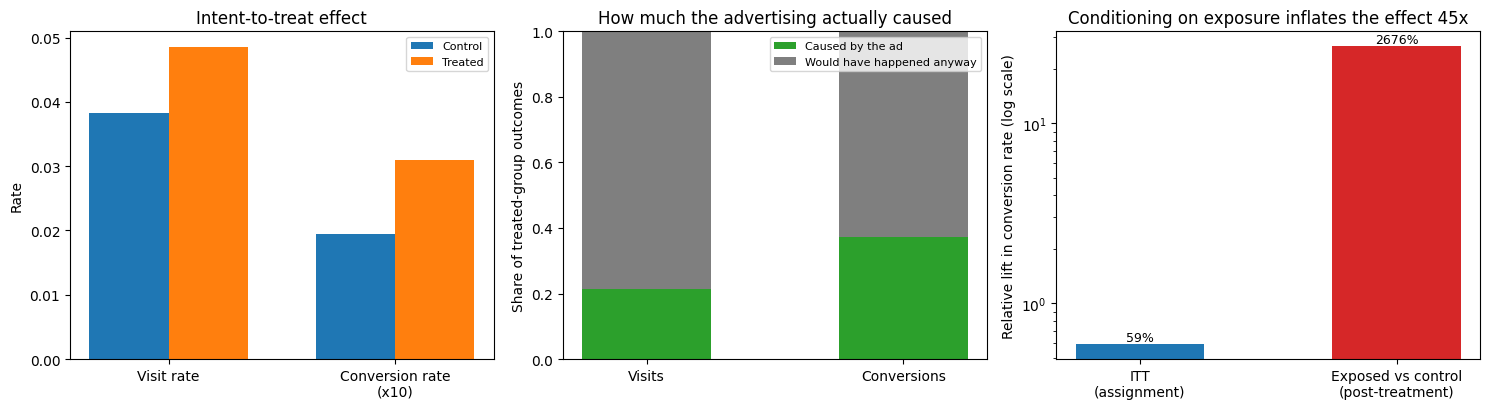

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

x = np.arange(2)
w = 0.35
r = itt.set_index('outcome')
ax[0].bar(x - w/2, [r.loc['visits','rate_control'],
                    r.loc['conversions','rate_control']*10],
          w, label='Control')
ax[0].bar(x + w/2, [r.loc['visits','rate_treated'],
                    r.loc['conversions','rate_treated']*10],
          w, label='Treated')
ax[0].set_xticks(x)
ax[0].set_xticklabels(['Visit rate', 'Conversion rate\n(x10)'])
ax[0].set(ylabel='Rate', title='Intent-to-treat effect')
ax[0].legend(fontsize=8)

sh = [r.loc['visits','incremental_share'],
      r.loc['conversions','incremental_share']]
ax[1].bar(x, sh, 0.5, color='tab:green', label='Caused by the ad')
ax[1].bar(x, [1-s for s in sh], 0.5, bottom=sh,
          color='tab:gray', label='Would have happened anyway')
ax[1].set_xticks(x)
ax[1].set_xticklabels(['Visits', 'Conversions'])
ax[1].set(ylim=(0, 1), ylabel='Share of treated-group outcomes',
          title='How much the advertising actually caused')
ax[1].legend(fontsize=8)

est = ['ITT\n(assignment)', 'Exposed vs control\n(post-treatment)']
vals = [r.loc['conversions','rel_lift'],
        wrong.set_index('grp').pipe(
            lambda t: (t.loc['exposed','conversions']/t.loc['exposed','n']) /
                      (t.loc['control','conversions']/t.loc['control','n']) - 1)]
ax[2].bar(est, vals, 0.5, color=['tab:blue', 'tab:red'])
ax[2].set_yscale('log')
ax[2].set(ylabel='Relative lift in conversion rate (log scale)',
          title='Conditioning on exposure inflates the effect 45x')
for i, v in enumerate(vals):
    ax[2].text(i, v, f'{v*100:.0f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{BASE}/figures/module_c_uplift.png')
plt.show()

In [13]:
out = {
    'dataset': {
        'version': 'criteo-research-uplift-v2.1',
        'rows': 13979592, 'treatment_ratio': 0.85,
        'visit_rate': 0.046992, 'conversion_rate': 0.00292,
        'exposure_rate_among_treated': 0.036037,
    },
    'group_counts': base.to_dict('records'),
    'itt': itt.to_dict('records'),
    'exposure_conditioning': wrong.to_dict('records'),
    'late': late_df.to_dict('records'),
    'paper_reproduction': {
        'target_visit_rel_lift': 0.270,
        'measured_visit_rel_lift': float(r.loc['visits','rel_lift']),
        'target_conversion_rel_lift': 0.594,
        'measured_conversion_rel_lift': float(r.loc['conversions','rel_lift']),
        'status': 'reproduced',
    },
    'notes': [
        'ITT relative lift reproduces the published figures to three '
        'significant digits: 27.07% on visits, 59.45% on conversions.',
        'Only 37.3% of conversions observed in the treated group are '
        'incremental; 62.7% would have occurred without the advertising.',
        'Only 3.6% of assigned users were actually exposed. Comparing '
        'exposed users against control inflates the conversion lift from '
        '59% to 2676%, a factor of 45.',
        'exposure is a post-treatment variable. Conditioning on it is the '
        'same error class as conditioning on total sequence length in '
        'module A.',
        'One-sided noncompliance identifies the LATE among compliers '
        'without conditioning on exposure.',
    ],
}

with open(f'{BASE}/output/module_c.json', 'w') as fh:
    json.dump(out, fh, indent=2)
print('saved:', os.path.getsize(f'{BASE}/output/module_c.json'), 'bytes')

saved: 3648 bytes
